This is the first session on Machine Learning


In [4]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, mean_absolute_error


There are small, built-in datasets available directly in scikit-learn:

load_iris: Iris flower dataset (classification).

load_digits: Digits dataset (classification).

load_wine: Wine recognition dataset (classification).

load_breast_cancer: Breast cancer Wisconsin dataset (classification).

load_boston: Boston housing prices dataset (regression) (Note: This has been removed due to ethical concerns).

load_diabetes: Diabetes dataset (regression).

load_linnerud: Linnerud dataset (multivariate regression).

load_lfw_people: Labeled Faces in the Wild (LFW) dataset for face recognition.

load_olivetti_faces: Olivetti faces dataset (face recognition).

load_20newsgroups: 20 newsgroups text dataset (text classification).

load_20newsgroups_vectorized: 20 newsgroups dataset with TF-IDF vectors.

load_sample_image: Sample images like China and Flower (used for image processing).

load_sample_images: A collection of sample images (used for image processing).

load_lfw_pairs: Labeled Faces in the Wild pairs dataset.


In [2]:
# Load California housing dataset
california_housing = fetch_california_housing()
data = california_housing.data
target = california_housing.target

# Display dataset information
print(california_housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived

Mean Squared Error: 0.5558915986952422
Mean Absolute Error: 0.533200130495698
Mean Squared Error: 1.4022809607834243e+23
Mean Absolute Error: 109003378753.21306
Intercept (bias term): [1.22506264e+08]
Coefficients: [-1.62360692e+09 -6.92272208e+07  2.96657013e+09  3.81653242e+08
  2.68455377e+08  5.07573643e+10 -3.93868004e+08 -1.43081817e+09]


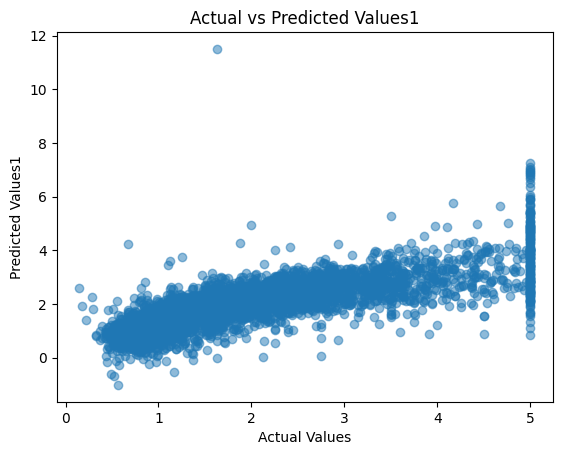

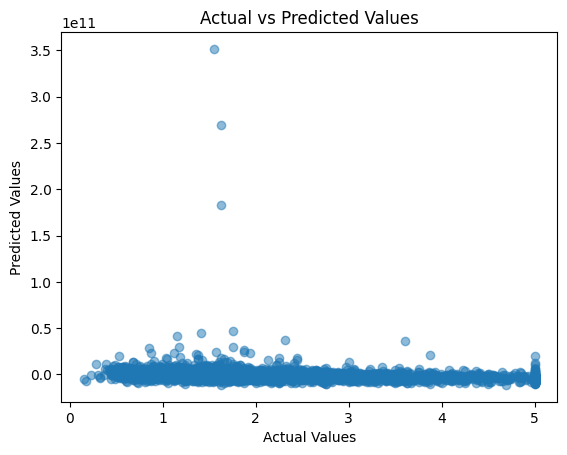

In [22]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

# Create and train the linear regression model
model1 = LinearRegression()
#model = SGDRegressor(learning_rate='constant', eta0=0.01, max_iter=1000, tol=1e-3)
#model = SGDRegressor(learning_rate='optimal',eta0=0.01, max_iter=1000, tol=1e-3 )
model = SGDRegressor(learning_rate='optimal', eta0=0.001, max_iter=1000000, tol=1e-3)


# Standardize the features (important for SGD)
scaler = StandardScaler()
X_train1 = scaler.fit_transform(X_train)
X_test1 = scaler.transform(X_test)

model.fit(X_train1, y_train)
#model1.fit(X_train, y_train)


# Make predictions on the test set
y_pred = model.predict(X_test1) #SGD Prediction
#y_pred1 = model1.predict(X_test)

# Evaluate the model
#mse1 = mean_squared_error(y_test, y_pred1)
#mae1 = mean_absolute_error(y_test, y_pred1)

print(f'Mean Squared Error: {mse1}')
print(f'Mean Absolute Error: {mae1}')
#print("Intercept (bias term):", model1.intercept_)
#print("Coefficients:", model1.coef_)

# Evaluate the model
#mse = mean_squared_error(y_test, y_pred)
#mae = mean_absolute_error(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print("Intercept (bias term):", model.intercept_)
print("Coefficients:", model.coef_)
plt.scatter(y_test, y_pred1, alpha=0.5)
plt.title('Actual vs Predicted Values1')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values1')
plt.show()

# Visualize the results
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

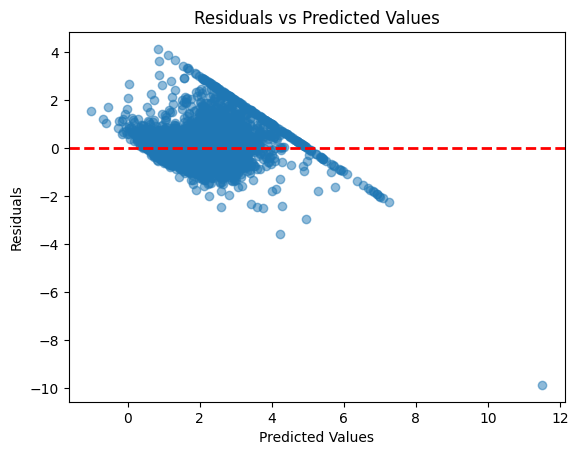

In [ ]:
# Calculate residuals
residuals = y_test - y_pred

# Plot residuals against predicted values
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)  # Reference line at y=0
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

**Basis Function Regression**
One trick you can use to adapt linear regression to nonlinear relationships between variables is to transform the data according to basis functions. We have seen one version of this before, in the PolynomialRegression pipeline used in Hyperparameters and Model Validation and Feature Engineering. The idea is to take our multidimensional linear model:
      y=a0+a1x1+a2x2+a3x3+⋯
and build the x1,x2,x3, and so on from our single-dimensional input x. That is, we let xn=fn(x), where fn() is some function that transforms our data.

For example, if fn(x)=xn, our model becomes a polynomial regression:
        y=a0+a1x+a2x2+a3x3+⋯
Notice that this is still a linear model—the linearity refers to the fact that the coefficients an never multiply or divide each other.

What we have effectively done is taken our one-dimensional x values and projected them into a higher dimension, so that a linear fit can fit more complicated relationships between x and y.

**Polynomial Basis Functions**

This polynomial projection is useful enough that it is built into Scikit-Learn, using the PolynomialFeatures transformer

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
x = np.array([2, 3, 4])
# Create PolynomialFeatures with degree 3 and exclude bias term
poly = PolynomialFeatures(3, include_bias=False)
poly.fit_transform(x[:, None])

array([[ 2.,  4.,  8.],
       [ 3.,  9., 27.],
       [ 4., 16., 64.]])

In [ ]:
from sklearn.pipeline import make_pipeline
# create polynomialFeature with degree 3 and then use linear regression
poly_model = make_pipeline(PolynomialFeatures(7),
                           LinearRegression())


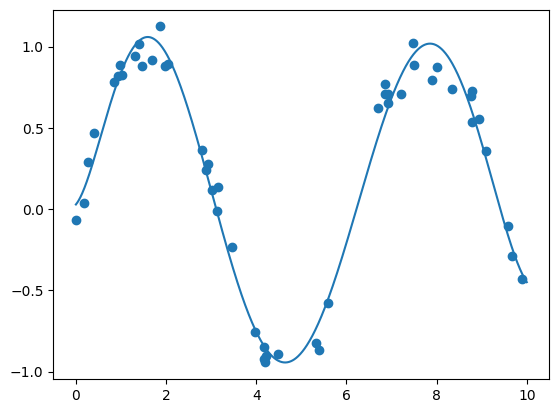

In [ ]:
rng = np.random.RandomState(1)
x = 10 * rng.rand(50)
y = np.sin(x) + 0.1 * rng.randn(50)

poly_model.fit(x[:, np.newaxis], y)
xfit = np.linspace(0, 10, 1000)
yfit = poly_model.predict(xfit[:, np.newaxis])

plt.scatter(x, y)
plt.plot(xfit, yfit);

**Gaussian Basis Functions**

Other basis functions are possible. For example, one useful pattern is to fit a model that is not a sum of polynomial bases, but a sum of Gaussian bases. The result might look something like the following figure:

These Gaussian basis functions are not built into Scikit-Learn, but we can write a custom transformer that will create them, as shown here and illustrated in the following figure (Scikit-Learn transformers are implemented as Python classes; reading Scikit-Learn's source is a good way to see how they can be created):

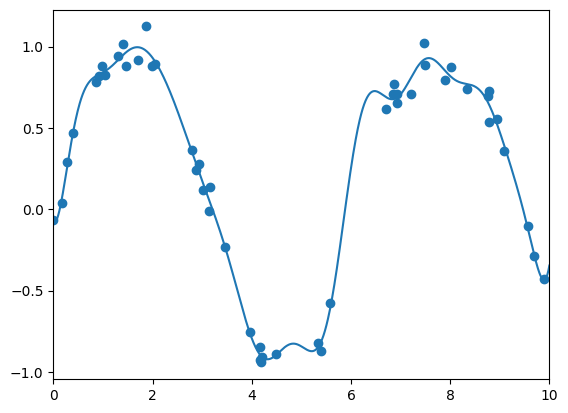

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class GaussianFeatures(BaseEstimator, TransformerMixin):
    """Uniformly spaced Gaussian features for one-dimensional input"""

    def __init__(self, N, width_factor=2.0):
        self.N = N
        self.width_factor = width_factor

    @staticmethod
    def _gauss_basis(x, y, width, axis=None):
        arg = (x - y) / width
        return np.exp(-0.5 * np.sum(arg ** 2, axis))

    def fit(self, X, y=None):
        # create N centers spread along the data range
        self.centers_ = np.linspace(X.min(), X.max(), self.N)
        self.width_ = self.width_factor * (self.centers_[1] - self.centers_[0])
        return self

    def transform(self, X):
        return self._gauss_basis(X[:, :, np.newaxis], self.centers_,
                                 self.width_, axis=1)

gauss_model = make_pipeline(GaussianFeatures(20),
                            LinearRegression())
gauss_model.fit(x[:, np.newaxis], y)
yfit = gauss_model.predict(xfit[:, np.newaxis])

plt.scatter(x, y)
plt.plot(xfit, yfit)
plt.xlim(0, 10);

**Regularization**

The introduction of basis functions into our linear regression makes the model much more flexible, but it also can very quickly lead to overfitting. For example, the following figure shows what happens if we use a large number of Gaussian basis functions:

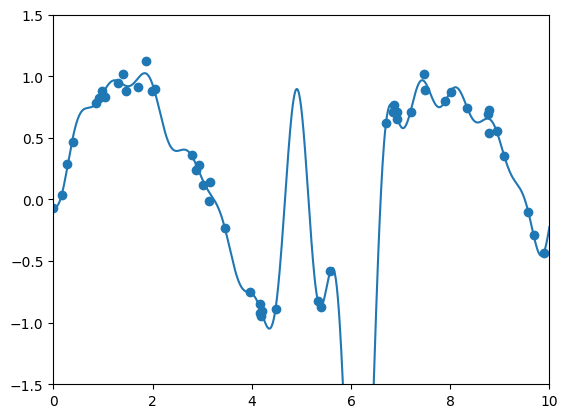

In [ ]:
model = make_pipeline(GaussianFeatures(30),
                      LinearRegression())
model.fit(x[:, np.newaxis], y)

plt.scatter(x, y)
plt.plot(xfit, model.predict(xfit[:, np.newaxis]))

plt.xlim(0, 10)
plt.ylim(-1.5, 1.5);

Note that, With the data projected to the 30-dimensional basis, the model has far too much flexibility and goes to extreme values between locations where it is constrained by data. We can see the reason for this if we plot the coefficients of the Gaussian bases with respect to their locations, as shown in the following figure:

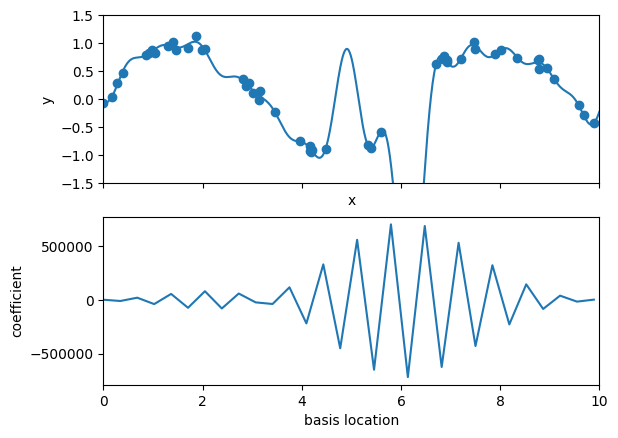

In [ ]:
def basis_plot(model, title=None):
    fig, ax = plt.subplots(2, sharex=True)
    model.fit(x[:, np.newaxis], y)
    ax[0].scatter(x, y)
    ax[0].plot(xfit, model.predict(xfit[:, np.newaxis]))
    ax[0].set(xlabel='x', ylabel='y', ylim=(-1.5, 1.5))

    if title:
        ax[0].set_title(title)

    ax[1].plot(model.steps[0][1].centers_,
               model.steps[1][1].coef_)
    ax[1].set(xlabel='basis location',
              ylabel='coefficient',
              xlim=(0, 10))

model = make_pipeline(GaussianFeatures(30), LinearRegression())
basis_plot(model)

The lower panel of this figure shows the amplitude of the basis function at each location. This is typical overfitting behavior when basis functions overlap: the coefficients of adjacent basis functions blow up and cancel each other out. We know that such behavior is problematic, and it would be nice if we could limit such spikes explicitly in the model by penalizing large values of the model parameters. Such a penalty is known as regularization, and comes in several forms.

**Regularization **

In complex regression model (i.e polynomials with higher order) overfitting is very likely.

As a solution we include regularization which proceeds by penalizing the sum of squares (2-norms) of the model coefficients

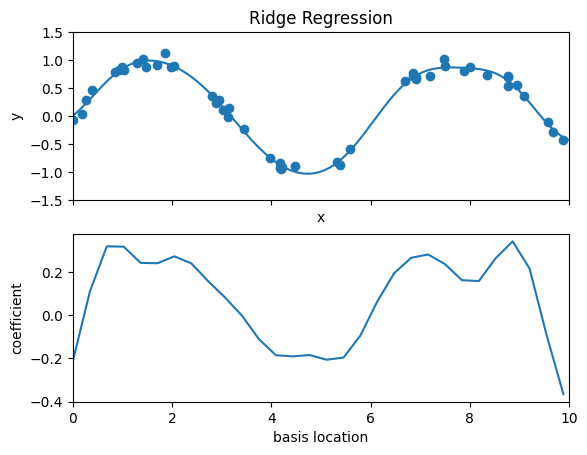

In [ ]:
from sklearn.linear_model import Ridge
model = make_pipeline(GaussianFeatures(30), Ridge(alpha=0.1))
basis_plot(model, title='Ridge Regression')

The  α  parameter is essentially a knob controlling the complexity of the resulting model. In the limit  α→0 , we recover the standard linear regression result; in the limit  α→∞ , all model responses will be suppressed. One advantage of ridge regression in particular is that it can be computed very efficiently—at hardly more computational cost than the original linear regression model.

**L1 Regression - Lasso regression**

Another common type of regularization is known as lasso regression or L1 regularization involves penalizing the sum of absolute values (1-norms) of regression coefficients:


Though this is conceptually very similar to ridge regression, the results can differ surprisingly. For example, due to its construction, lasso regression tends to favor sparse models where possible: that is, it preferentially sets many model coefficients to exactly zero.

We can see this behavior if we duplicate the previous example using L1-normalized coefficients (see the following figure):

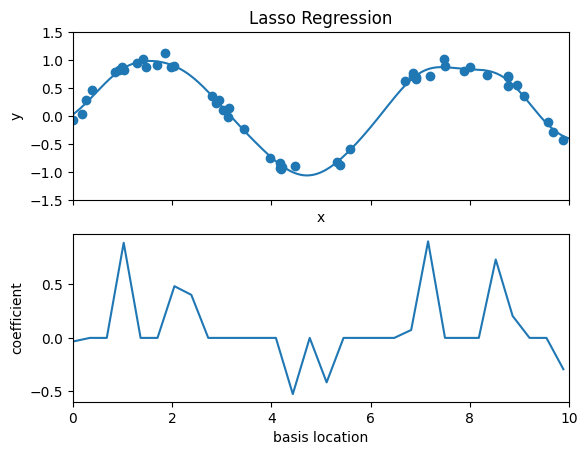

In [ ]:
from sklearn.linear_model import Lasso
model = make_pipeline(GaussianFeatures(30), Lasso(alpha=0.001, max_iter=2000))
basis_plot(model, title='Lasso Regression')